<a href="https://colab.research.google.com/github/Adyypower/Deep-learning-Models-or-topics/blob/main/SSD_tensrflow_2_object_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install compatible versions
!pip install tensorflow==2.17.0
!pip install tf-models-official==2.17.0
!pip install protobuf~=3.20.0
!pip install opencv-python==4.8.0.74 opencv-contrib-python==4.8.0.74
!pip install numpy==1.26.4

  Using cached tf_models_official-2.17.0-py2.py3-none-any.whl.metadata (1.4 kB)
INFO: pip is looking at multiple versions of tf-models-official to determine which version is compatible with other requirements. This could take a while.
ERROR: Could not find a version that satisfies the requirement tensorflow-text~=2.17.0 (from tf-models-official) (from versions: 2.18.1, 2.19.0rc0, 2.19.0)
ERROR: No matching distribution found for tensorflow-text~=2.17.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-decision-forests 

In [ ]:
# 2. Clone the TensorFlow models repo (Object Detection API)
!git clone https://github.com/tensorflow/models.git


Cloning into 'models'...
remote: Enumerating objects: 102275, done.
remote: Counting objects: 100% (323/323), done.
remote: Compressing objects: 100% (176/176), done.
remote: Total 102275 (delta 219), reused 147 (delta 147), pack-reused 101952 (from 4)
Receiving objects: 100% (102275/102275), 644.67 MiB | 24.61 MiB/s, done.
Resolving deltas: 100% (72885/72885), done.


In [ ]:
# 3. Compile Protobufs
!apt-get install -q protobuf-compiler python3-dev
%cd /content/models/research
!protoc object_detection/protos/*.proto --python_out=.


Reading package lists...
Building dependency tree...
Reading state information...
python3-dev is already the newest version (3.10.6-1~22.04.1).
python3-dev set to manually installed.
protobuf-compiler is already the newest version (3.12.4-1ubuntu7.22.04.4).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/content/models/research


In [ ]:
# Install Object Detection API
!cp object_detection/packages/tf2/setup.py .
!python -m pip install .


Processing /content/models/research
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 4.6 MB/s eta 0:00:00
  Using cached tensorflow_model_optimization-0.8.0-py2.py3-none-any.whl.metadata (904 bytes)
  Using cached seqeval-1.2.2.tar.gz (43 kB)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of pymilvus to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python-headless to det

In [ ]:
# Test installation
!python object_detection/builders/model_builder_tf2_test.py


2025-08-22 04:32:51.452213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755837171.496194    2867 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755837171.507256    2867 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755837171.544977    2867 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755837171.545045    2867 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755837171.545051    2867 computation_placer.cc:177] computation placer alr

In [65]:
import os
import pathlib
import tensorflow as tf
import time
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)

In [36]:
# Download example images
!wget -O image1.jpg https://www.tensorflow.org/images/od_flowers.jpg
!wget -O image2.jpg https://www.tensorflow.org/images/od_pets.jpg
!wget -O image3.jpg https://www.tensorflow.org/images/od_cars.jpg

--2025-08-22 05:48:44--  https://www.tensorflow.org/images/od_flowers.jpg
Resolving www.tensorflow.org (www.tensorflow.org)... 173.194.194.100, 173.194.194.102, 173.194.194.101, ...
Connecting to www.tensorflow.org (www.tensorflow.org)|173.194.194.100|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-08-22 05:48:44 ERROR 404: Not Found.

--2025-08-22 05:48:44--  https://www.tensorflow.org/images/od_pets.jpg
Resolving www.tensorflow.org (www.tensorflow.org)... 173.194.194.100, 173.194.194.102, 173.194.194.101, ...
Connecting to www.tensorflow.org (www.tensorflow.org)|173.194.194.100|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-08-22 05:48:44 ERROR 404: Not Found.

--2025-08-22 05:48:44--  https://www.tensorflow.org/images/od_cars.jpg
Resolving www.tensorflow.org (www.tensorflow.org)... 173.194.194.100, 173.194.194.102, 173.194.194.101, ...
Connecting to www.tensorflow.org (www.tensorflow.org)|173.194.194.100|:443... connected.

Let's download some example images.

In [ ]:
!ls

image1.jpg  image2.jpg	image3.jpg  models  sample_data


In [37]:
IMAGE_PATH = ['/content/image1.jpg','/content/image2.jpg','/content/image3.jpg']

In [ ]:
url = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_resnet101_v1_fpn_640x640_coco17_tpu-8.tar.gz'

PATH_TO_MODEL_DIR = tf.keras.utils.get_file(
    fname='ssd_resnet101_v1_fpn_640x640_coco17_tpu-8',
    origin=url,
    untar=True)


386527459/386527459 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [ ]:
PATH_TO_MODEL_DIR

'/root/.keras/datasets/ssd_resnet101_v1_fpn_640x640_coco17_tpu-8'

In [ ]:
url = "https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/data/mscoco_label_map.pbtxt"

PATH_TO_LABELS = tf.keras.utils.get_file(
    fname='mscoco_label_map.pbtxt',
    origin=url,
    untar=False
)

5056/5056 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
!head {PATH_TO_LABELS}

item {
  name: "/m/01g317"
  id: 1
  display_name: "person"
}
item {
  name: "/m/0199g"
  id: 2
  display_name: "bicycle"
}


In [34]:
PATH_TO_SAVED_MODEL = os.path.join(PATH_TO_MODEL_DIR, 'ssd_resnet101_v1_fpn_640x640_coco17_tpu-8', 'saved_model')

print('loading model...', end= ' ')
start_time = time.time()
#load saved modeland build the detection function

detect_fn = tf.saved_model.load(PATH_TO_SAVED_MODEL)

end_time = time.time()
elapsed_time = end_time - start_time
print('Done! Took {} seconds'.format(elapsed_time))

loading model... Done! Took 83.04992437362671 seconds


In [ ]:
import os

print(os.listdir(PATH_TO_MODEL_DIR))

['ssd_resnet101_v1_fpn_640x640_coco17_tpu-8']


In [ ]:
category_index = label_map_util.create_category_index_from_labelmap(PATH_TO_LABELS, use_display_name=True)

In [ ]:
category_index

{1: {'id': 1, 'name': 'person'},
 2: {'id': 2, 'name': 'bicycle'},
 3: {'id': 3, 'name': 'car'},
 4: {'id': 4, 'name': 'motorcycle'},
 5: {'id': 5, 'name': 'airplane'},
 6: {'id': 6, 'name': 'bus'},
 7: {'id': 7, 'name': 'train'},
 8: {'id': 8, 'name': 'truck'},
 9: {'id': 9, 'name': 'boat'},
 10: {'id': 10, 'name': 'traffic light'},
 11: {'id': 11, 'name': 'fire hydrant'},
 13: {'id': 13, 'name': 'stop sign'},
 14: {'id': 14, 'name': 'parking meter'},
 15: {'id': 15, 'name': 'bench'},
 16: {'id': 16, 'name': 'bird'},
 17: {'id': 17, 'name': 'cat'},
 18: {'id': 18, 'name': 'dog'},
 19: {'id': 19, 'name': 'horse'},
 20: {'id': 20, 'name': 'sheep'},
 21: {'id': 21, 'name': 'cow'},
 22: {'id': 22, 'name': 'elephant'},
 23: {'id': 23, 'name': 'bear'},
 24: {'id': 24, 'name': 'zebra'},
 25: {'id': 25, 'name': 'giraffe'},
 27: {'id': 27, 'name': 'backpack'},
 28: {'id': 28, 'name': 'umbrella'},
 31: {'id': 31, 'name': 'handbag'},
 32: {'id': 32, 'name': 'tie'},
 33: {'id': 33, 'name': 'suitc

In [54]:
def load_image_into_numpy_array(path):
  """ load an image from file into a numpy array.
  Puts image into numpy array to feed into tensorflow graph.
  Note that by convention we put it into a numpy array with shape
  (height, width, channels), where channels=3 for RGB.

  Args:
  path: the file path to the image

  returns:
  uint8 numpy array with shape (img_height,img_width,3)
  """
  return np.array(Image.open(path))

**Do some object detection**

In [66]:
def detect_objects(image_path):
    # Load image
    image_np = np.array(Image.open(image_path))

    # Convert to tensor
    input_tensor = tf.convert_to_tensor(image_np)
    input_tensor = input_tensor[tf.newaxis, ...]

    # Run detection
    detections = detect_fn(input_tensor)

    # Extract detection results
    num_detections = int(detections.pop('num_detections'))
    detections = {key: value[0, :num_detections].numpy()
                  for key, value in detections.items()}
    detections['num_detections'] = num_detections
    detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

    # Visualize results
    from object_detection.utils import visualization_utils as viz_utils
    image_np_with_detections = image_np.copy()

    viz_utils.visualize_boxes_and_labels_on_image_array(
        image_np_with_detections,
        detections['detection_boxes'],
        detections['detection_classes'],
        detections['detection_scores'],
        category_index,
        use_normalized_coordinates=True,
        max_boxes_to_draw=200,
        min_score_thresh=.30,
        agnostic_mode=False)

    # Show in Colab (inline)
    plt.figure(figsize=(12, 8))
    plt.imshow(image_np_with_detections)
    plt.axis("off")
    plt.show()

In [42]:
import requests

image_url = 'https://raw.githubusercontent.com/zhreshold/mxnet-ssd/master/data/demo/dog.jpg'
image_path = 'dog.jpg'

# download the image
response = requests.get(image_url, stream=True)
if response.status_code == 200:
    with open(image_path, 'wb') as f:
        f.write(response.content)
    print("Image downloaded:", image_path)
else:
    print("Failed to download image")



Image downloaded: dog.jpg


In [40]:
image_url = 'https://raw.githubusercontent.com/zhreshold/mxnet-ssd/master/data/demo/dog.jpg'
image_path = 'dog.jpg'

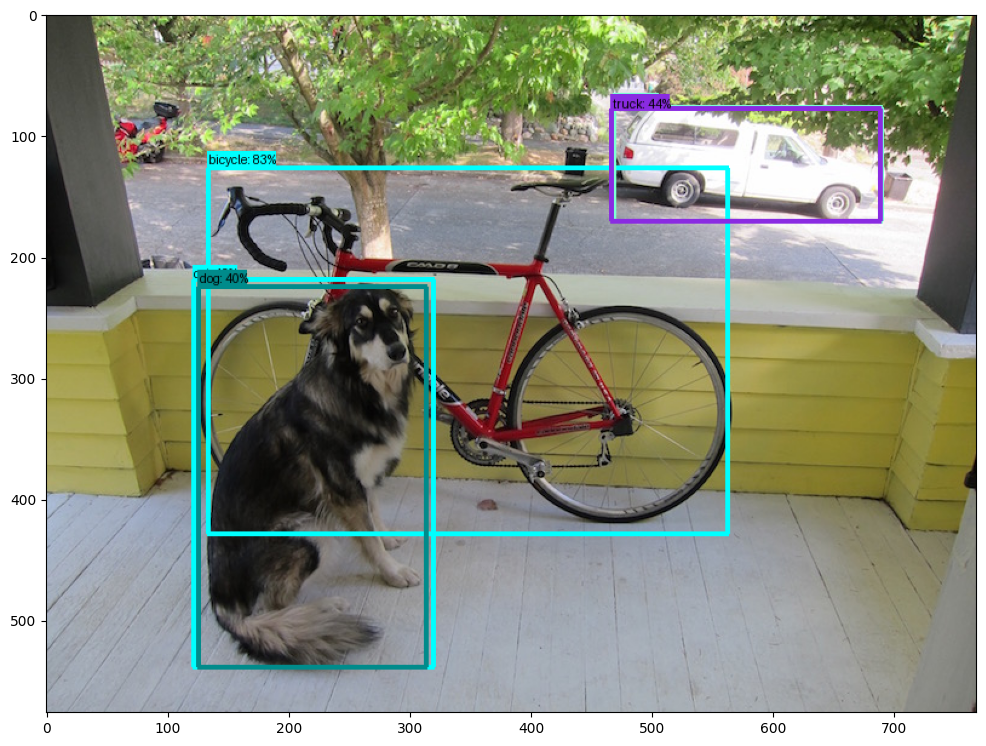

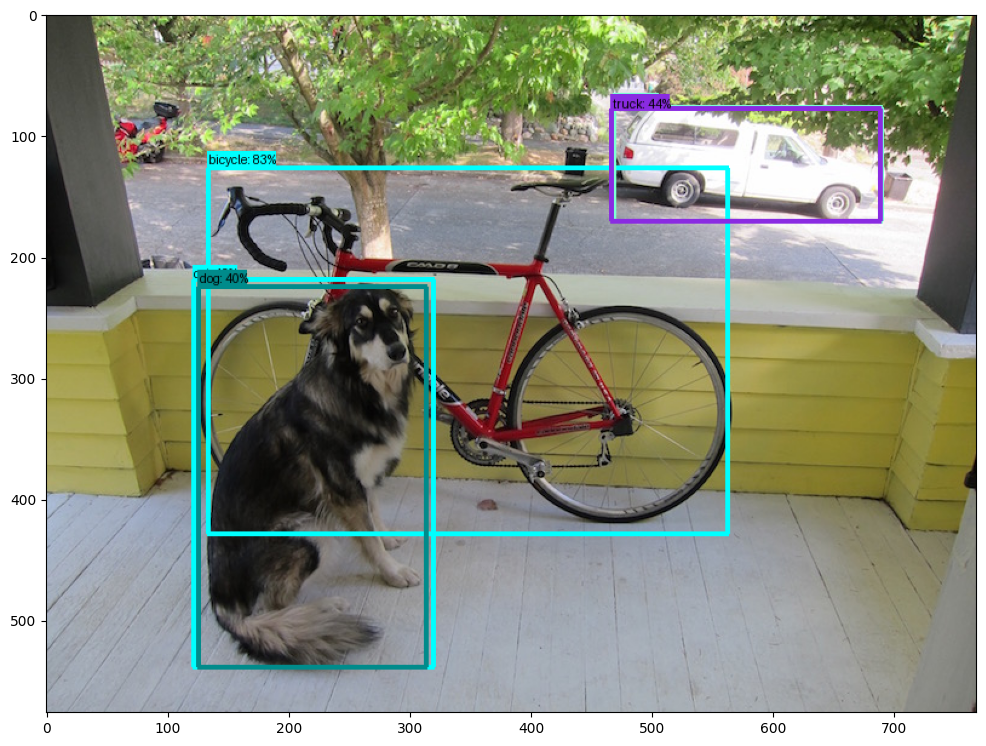

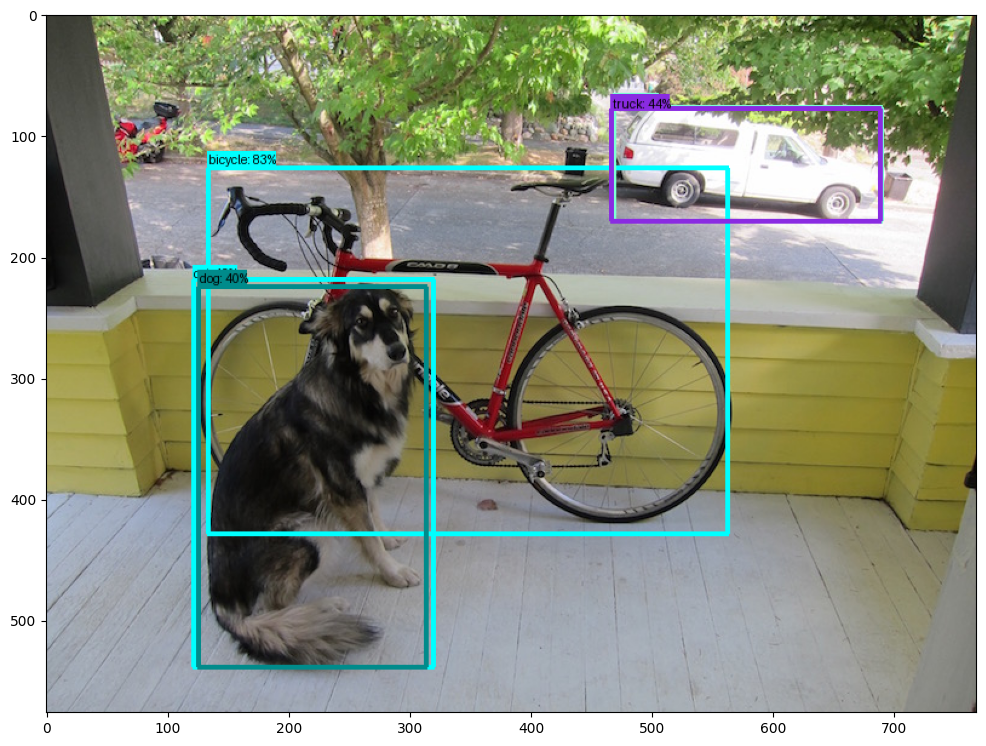

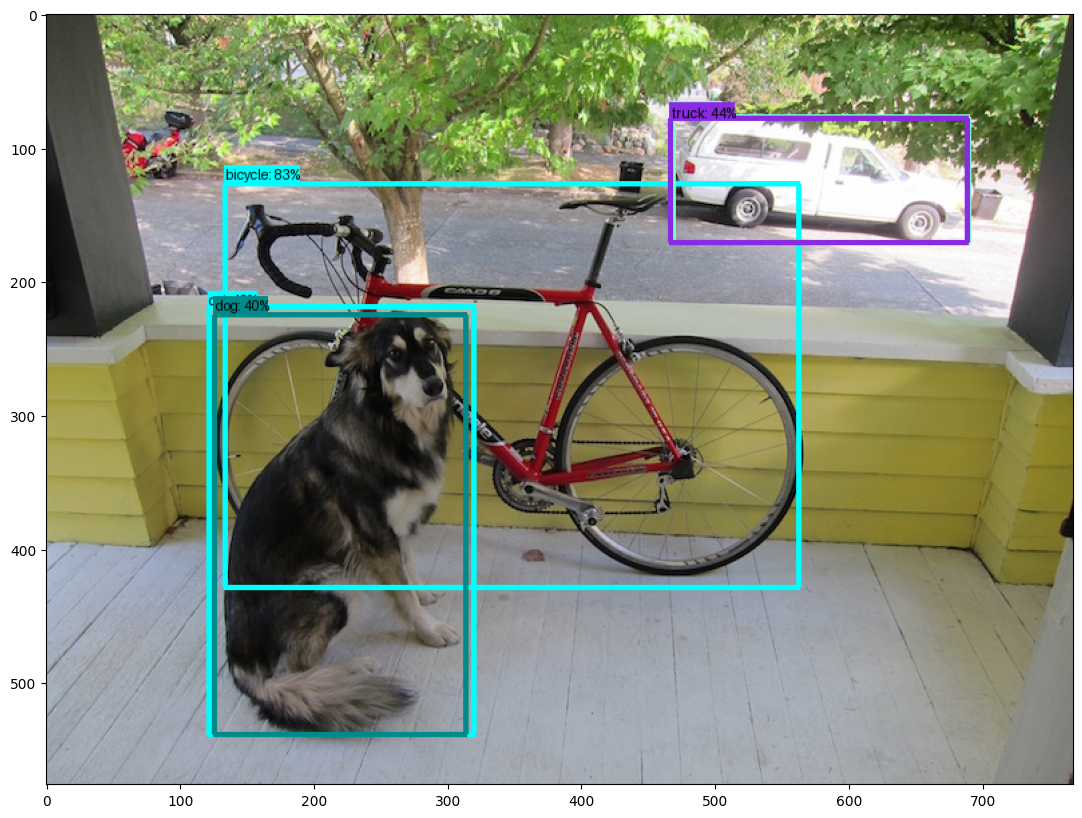

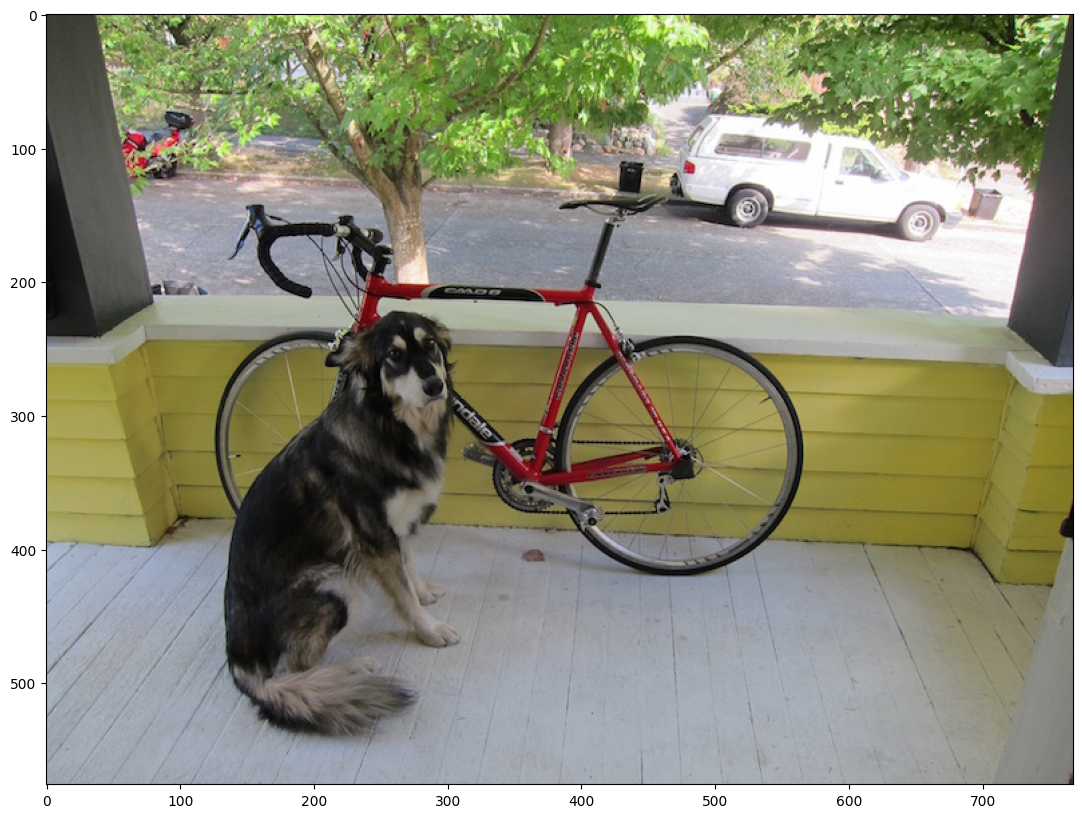

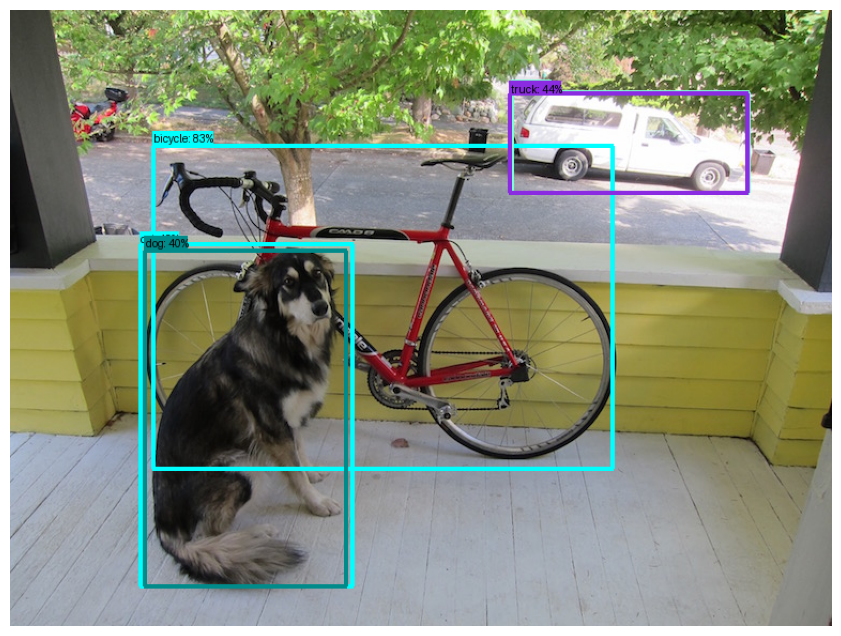

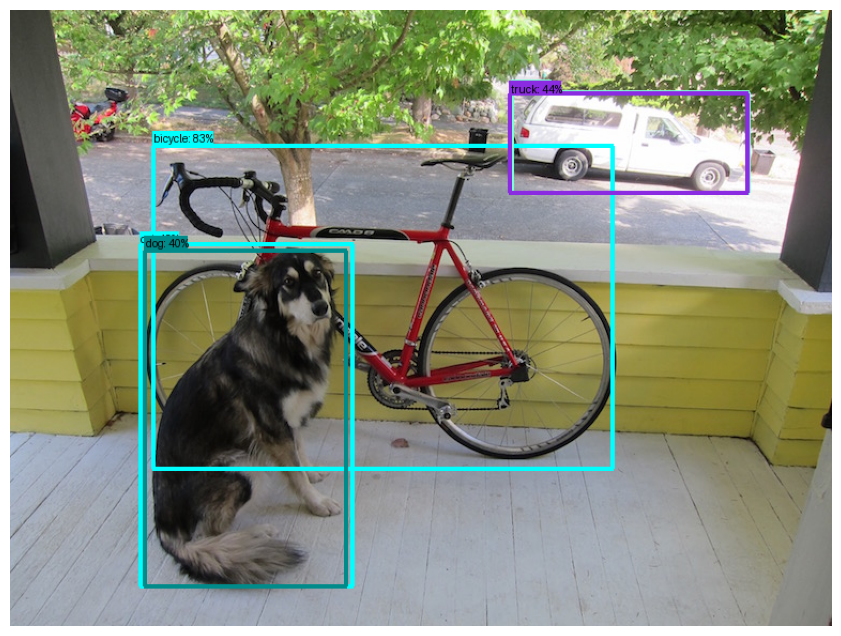

In [67]:
detect_objects('/content/dog.jpg')